## How to run our algorithm on a bifiltered graph
Input: 
- graph: $G = (V,E)$
- function $f: G \rightarrow \mathbb R^2$ satisfying 
    - for any $e = (u,v) \in E$, $f(u), f(v) \leq f(e)$
    - $f$ is one-critical


In [2]:
import graph_mph
import matplotlib.pyplot as plt
import numpy as np

# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="firep",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    file_path="test_fil.firep",
)

graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

In [3]:
print(f"x coordinates: {bifi.get_x_coords()}")
print(f"y coordinates: {bifi.get_y_coords()}")

x coordinates: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135]
y coordinates: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [4]:
res

{'b_0': [(0, 0),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (0, 5),
  (0, 6),
  (0, 7),
  (0, 8),
  (0, 9),
  (0, 10),
  (0, 11),
  (0, 12),
  (0, 13),
  (0, 14),
  (0, 15),
  (0, 16),
  (0, 17),
  (0, 18),
  (0, 19),
  (0, 20),
  (0, 21)],
 'b_1': [(1, 9),
  (2, 16),
  (3, 7),
  (4, 7),
  (5, 19),
  (6, 4),
  (7, 9),
  (8, 21),
  (9, 10),
  (10, 15),
  (11, 8),
  (12, 6),
  (13, 10),
  (15, 4),
  (17, 3),
  (19, 17),
  (21, 16),
  (22, 15),
  (23, 6),
  (25, 18),
  (28, 3),
  (30, 21),
  (31, 15),
  (33, 12),
  (37, 17),
  (39, 14),
  (40, 14),
  (43, 7),
  (45, 5),
  (47, 18),
  (49, 13),
  (51, 21),
  (53, 20),
  (59, 5),
  (63, 3),
  (68, 13),
  (78, 2),
  (92, 2),
  (96, 11),
  (110, 1)],
 'b_2': [(11, 9),
  (12, 7),
  (17, 4),
  (22, 16),
  (28, 10),
  (31, 21),
  (39, 15),
  (40, 15),
  (43, 17),
  (45, 6),
  (49, 18),
  (53, 21),
  (59, 7),
  (63, 5),
  (68, 14),
  (78, 3),
  (92, 3),
  (96, 13),
  (110, 2)],
 'b_0_1': [(11, 9),
  (12, 7),
  (14, 10),
  (16, 9),
  (17, 4),
  (18

In [5]:
def compute_approximated_Hilbert_matrix(
    res: dict[str, list[tuple[int, int]]],
    table_x_coords: list[float],
    table_y_coords: list[float],
    target_matrix_shape: tuple[int, int],
):
    # convert the graded betti numbers in indices to filtration values
    b_0_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_0"], table_x_coords, table_y_coords
    )
    b_0_values = np.array(b_0_values)
    b_1_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_1"], table_x_coords, table_y_coords
    )
    b_1_values = np.array(b_1_values)
    b_2_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_2"], table_x_coords, table_y_coords
    )
    b_2_values = np.array(b_2_values)

    target_m, target_n = target_matrix_shape
    xs = np.linspace(table_x_coords[0], table_x_coords[-1], target_m)
    ys = np.linspace(table_y_coords[0], table_y_coords[-1], target_n)
    matrix_meshgrid = np.meshgrid(xs, ys, indexing="ij")

    cumsum_b_0 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_1 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_2 = np.zeros((target_m, target_n), dtype=np.int32)
    for i in range(target_m):
        for j in range(target_n):
            s, k = matrix_meshgrid[0][i][j], matrix_meshgrid[1][i][j]
            # counts the number of rows (x,y) in b_0_values that satisfy x <= s and y <= k
            cumsum_b_0[i, j] = np.sum((b_0_values[:, 0] <= s) & (b_0_values[:, 1] <= k))
            cumsum_b_1[i, j] = np.sum((b_1_values[:, 0] <= s) & (b_1_values[:, 1] <= k))
            cumsum_b_2[i, j] = np.sum((b_2_values[:, 0] <= s) & (b_2_values[:, 1] <= k))

    return cumsum_b_0, cumsum_b_1, cumsum_b_2

Q: what is the table_x_coords? Does it have to be unique? 

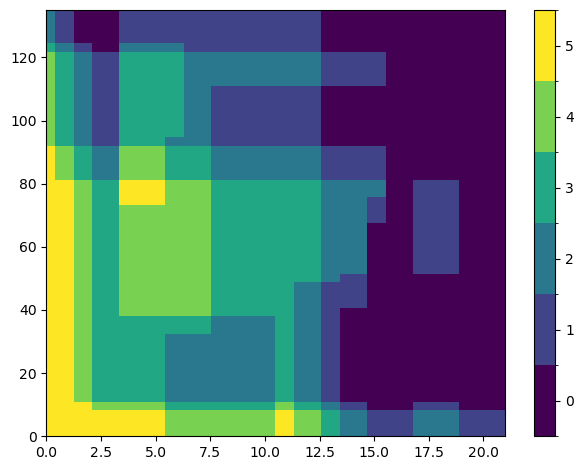

In [6]:
# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = np.load("x_coords.npy")
table_y_coords = np.load("y_coords.npy")

# compute the approximated Hilbert matrix
cum_0, cum_1, cum_2 = compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs ball density)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = graph_mph.draw_discrete_matrix(
    matrix_to_plot, x_axis_range=yrange, y_axis_range=xrange, origin="lower"
)
discrete_plot.tight_layout()
# discrete_plot.savefig("Hibert_matrix_ball_density_rips_blob_400.pdf", dpi=300)
discrete_plot.show()